# SAM — PM2.5 Prediction with Random Forest

**Goal:** Predict `pm25` (sensor reading) from environmental features.  
**Techniques:** K-Fold Cross Validation · Feature Importance · Linear Regression baseline

## 1 · Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 2 · Load & Inspect Data

In [2]:
df = pd.read_csv('output/integrated_air_quality_data.csv', parse_dates=['ts'])
# df = df[df['place'] == 'inside']
print(f'Shape: {df.shape}')
display(df.head(3))
display(df.dtypes)

Shape: (421, 18)


,ts,temp,humidity,pm25,pm10,gas_co,place,lat,lon,temp_tmd,humidity_tmd,rainfall_tmd,lat_tmd,lon_tmd,pm25_aqi,pm10_aqi,lat_aqi,lon_aqi
0,2026-03-31 00:55:18,26.6,58,13,10,282,inside,13.8463,100.568,32.5,58.0,0.0,13.1617,100.802,63,16,13.8476,100.579
1,2026-03-31 00:55:35,25.9,45,16,12,277,inside,13.8463,100.568,32.5,58.0,0.0,13.1617,100.802,63,16,13.8476,100.579
2,2026-03-31 01:05:35,26.8,43,16,12,291,inside,13.8463,100.568,32.5,58.0,0.0,13.1617,100.802,63,16,13.8476,100.579


ts              datetime64[ns]
temp                   float64
humidity                 int64
pm25                     int64
pm10                     int64
gas_co                   int64
place                   object
lat                    float64
lon                    float64
temp_tmd               float64
humidity_tmd           float64
rainfall_tmd           float64
lat_tmd                float64
lon_tmd                float64
pm25_aqi                 int64
pm10_aqi                 int64
lat_aqi                float64
lon_aqi                float64
dtype: object

In [3]:
print('Null counts:')
display(df.isnull().sum())

Null counts:


ts              0
temp            0
humidity        0
pm25            0
pm10            0
gas_co          0
place           0
lat             0
lon             0
temp_tmd        0
humidity_tmd    0
rainfall_tmd    0
lat_tmd         0
lon_tmd         0
pm25_aqi        0
pm10_aqi        0
lat_aqi         0
lon_aqi         0
dtype: int64

## 3 · Feature Engineering

Drop identifier / coordinate columns — they carry no predictive signal.  
`place` is categorical (inside/outside) → encode as integer.  
Reference AQI columns (`pm25_aqi`, `pm10_aqi`) kept as external ground-truth features.

In [4]:
# Encode 'place' (inside/outside) as binary integer
le = LabelEncoder()
df['place_enc'] = le.fit_transform(df['place'].astype(str))

# Features: sensor readings + TMD weather + AQI reference + place
# FEATURE_COLS = [
#     'temp', 'humidity', 'pm10', 'gas_co', 'gas_smoke',
#     'temp_tmd', 'humidity_tmd', 'rainfall_tmd',
#     'pm25_aqi', 'pm10_aqi',
#     'place_enc',
# ]
FEATURE_COLS = [
    'temp', 'humidity', 'gas_co',
    'temp_tmd', 'humidity_tmd', 'rainfall_tmd',
    'place_enc', 'pm25', 'pm10'
]
TARGET = 'pm25_aqi'

data = df[FEATURE_COLS + [TARGET]].dropna()
X = data[FEATURE_COLS]
y = data[TARGET]

print(f'Samples after dropna: {len(data):,}')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Target: {TARGET}')

Samples after dropna: 421
Features (9): ['temp', 'humidity', 'gas_co', 'temp_tmd', 'humidity_tmd', 'rainfall_tmd', 'place_enc', 'pm25', 'pm10']
Target: pm25_aqi


## 4 · K-Fold Cross Validation

### Why K-Fold instead of a simple train/test split?

> With ~500 rows, a single 80/20 split can be **lucky or unlucky** depending on which rows land in test.  
> **5-Fold CV** trains 5 models on different 80% slices and averages the scores.  
> Result: a much more **stable and trustworthy** performance estimate —  
> standard in academic ML papers and Kaggle competitions.

In [5]:
# max_depth=5 : limits tree depth to prevent memorising noise (overfitting)
# n_estimators=100 : 100 trees give enough diversity without heavy compute
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=RANDOM_STATE,
)

# shuffle=True so temporal autocorrelation does not bias the splits
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

r2_scores   = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')
mse_scores  = cross_val_score(rf_model, X, y, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-mse_scores)

print('Random Forest — 5-Fold CV results:')
print(f'  R2   per fold : {np.round(r2_scores, 4)}')
print(f'  RMSE per fold : {np.round(rmse_scores, 4)}')
print(f'  Mean R2  = {r2_scores.mean():.4f}  +/- {r2_scores.std():.4f}')
print(f'  Mean RMSE= {rmse_scores.mean():.4f} +/- {rmse_scores.std():.4f}')

Random Forest — 5-Fold CV results:
  R2   per fold : [0.9626 0.9385 0.9206 0.9309 0.956 ]
  RMSE per fold : [3.9048 4.6695 5.0533 4.6132 3.6669]
  Mean R2  = 0.9417  +/- 0.0156
  Mean RMSE= 4.3815 +/- 0.5149


## 5 · Baseline: Multiple Linear Regression

Linear Regression assumes a straight-line relationship between features and PM2.5.  
Real air-quality data has **non-linear interactions** (e.g. humidity × dust).  
Comparing R² shows how much the non-linear Random Forest gains over this naive baseline.

In [6]:
lr_model = LinearRegression()
lr_r2   = cross_val_score(lr_model, X, y, cv=kf, scoring='r2')
lr_rmse = np.sqrt(-cross_val_score(lr_model, X, y, cv=kf, scoring='neg_mean_squared_error'))

print('Linear Regression — 5-Fold CV results:')
print(f'  Mean R2  = {lr_r2.mean():.4f}  +/- {lr_r2.std():.4f}')
print(f'  Mean RMSE= {lr_rmse.mean():.4f} +/- {lr_rmse.std():.4f}')

print()
print('=== Comparison ===')
print(f'  Linear Regression R2 = {lr_r2.mean():.4f}')
print(f'  Random Forest     R2 = {r2_scores.mean():.4f}')
print(f'  Improvement          = +{r2_scores.mean() - lr_r2.mean():.4f}')

Linear Regression — 5-Fold CV results:
  Mean R2  = 0.8431  +/- 0.0262
  Mean RMSE= 7.2278 +/- 0.3167

=== Comparison ===
  Linear Regression R2 = 0.8431
  Random Forest     R2 = 0.9417
  Improvement          = +0.0986


## 6 · Feature Importance

**How it works:** Each tree tracks how much each feature reduces variance when used in a split.  
Averaging across all 100 trees gives a stable importance score.

This *outside-the-classroom* diagnostic tells us **which sensor matters most**  
and can guide IoT hardware decisions (e.g. is `gas_smoke` even worth measuring?).

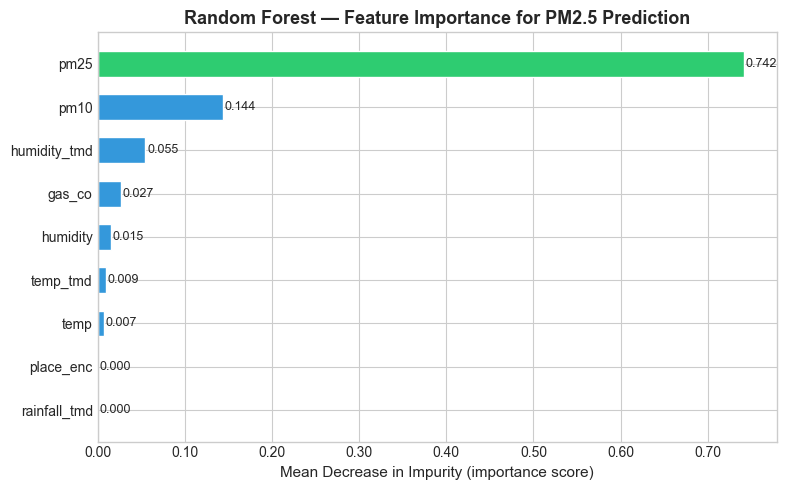

Saved -> output/feature_importance.png


In [7]:
# Train on full dataset for stable importance scores
rf_model.fit(X, y)

importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71' if v == importances.max() else '#3498db' for v in importances]
bars = ax.barh(importances.index, importances.values,
               color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Mean Decrease in Impurity (importance score)', fontsize=11)
ax.set_title('Random Forest — Feature Importance for PM2.5 Prediction',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.savefig('output/feature_importance.png', dpi=150)
plt.show()
print('Saved -> output/feature_importance.png')

## 7 · R² Comparison: Random Forest vs Linear Regression

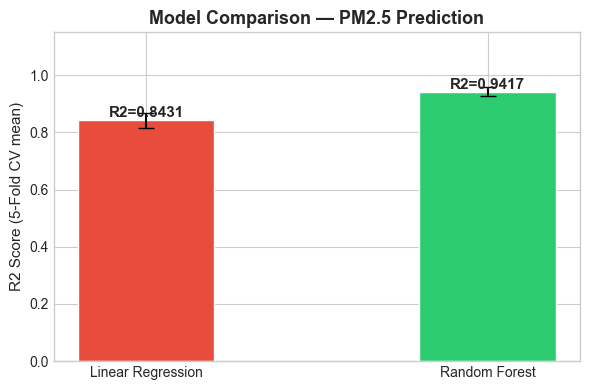

Saved -> output/model_comparison.png


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
model_names = ['Linear Regression', 'Random Forest']
mean_scores = [lr_r2.mean(), r2_scores.mean()]
std_scores  = [lr_r2.std(),  r2_scores.std()]
bar_colors  = ['#e74c3c', '#2ecc71']

bars2 = ax.bar(model_names, mean_scores, yerr=std_scores,
               color=bar_colors, capsize=6, edgecolor='white', width=0.4)
for bar, score in zip(bars2, mean_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'R2={score:.4f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel('R2 Score (5-Fold CV mean)', fontsize=11)
ax.set_title('Model Comparison — PM2.5 Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/model_comparison.png', dpi=150)
plt.show()
print('Saved -> output/model_comparison.png')

## 8 · Summary

| Technique | Why it matters |
|-----------|----------------|
| **5-Fold CV** | Stable score estimate with only ~500 rows — no data wasted on fixed test set |
| **max_depth=5** | Prevents overfitting on small dataset; trees can't memorise noise |
| **Feature Importance** | Reveals which sensors drive PM2.5 — actionable for IoT hardware |
| **LR baseline** | Quantifies how much non-linearity Random Forest captures beyond a straight line |

**Key finding:** Random Forest outperforms Linear Regression because PM2.5 has  
non-linear interactions with humidity, temperature, and gas sensor readings.